# Frozen test comparison: uncertainty, errors and cost dimensions

This notebook analyses existing NYT10m test predictions under `nyt10m_selected_evidence_test_v1_20261007`. It compares **large0.7**, the frozen **base0.5 / large0.7 / GLiDRE0.7 two-of-three majority**, and **DeepSeek thinking-low** on the same **5,174 bags**, using the official manual labels of the selected evidence.

**Run All displays the published analysis.** It neither downloads assets, loads checkpoints, sends requests nor generates predictions. The optional flags below only repeat numerical analysis or regenerate figures. No test-based threshold, prompt or fusion selection is performed.

In [1]:
# Locate the repository and load the compact, identity-checked analysis.
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'results/test_comparison_spec.json').exists():
    ROOT = ROOT.parent
if not (ROOT / 'source/analyze_test_results.py').is_file():
    raise FileNotFoundError('Open this notebook from the repository or source directory.')
sys.path.insert(0, str(ROOT / 'source'))
from analyze_test_results import load_public_analysis, paired_intervals, NAMES, SYSTEMS

RECOMPUTE_BOOTSTRAP = False
REGENERATE_FIGURES = False

report, counts = load_public_analysis(ROOT)
print('Frozen fingerprint:', report['fingerprint'])
print(f'{len(counts):,} complete paired bags; {report["uncertainty"]["replicates"]:,} saved bootstrap replicates')
print('No model inference or API execution is available in this notebook.')

Frozen fingerprint: b7ab3463602ffb361ff4ecdbc37ce947b0bca7b9cbcfa0221e7761ab3de3f6a3
5,174 complete paired bags; 20,000 saved bootstrap replicates
No model inference or API execution is available in this notebook.


## 1. Primary quality estimates

Each positive `(ordered entity pair, relation)` decision contributes to TP, FP or FN. The empty set represents `NA`. All 78 invalid API answers remain empty predictions under the original rule; they are also reported separately. Negative bags stay in the analysis because unsupported predictions on these bags contribute false positives.

In [2]:
# Present precision, recall and micro-F1 without changing the scorer or cutoffs.
quality_rows = []
for name, row in zip(NAMES, report['primary_rows'], strict=True):
    quality_rows.append({'System': name, 'TP': row['TP'], 'FP': row['FP'], 'FN': row['FN'],
                         'Precision %': 100 * row['precision'], 'Recall %': 100 * row['recall'],
                         'Micro-F1 %': 100 * row['micro_f1'], 'Invalid': row['invalid']})
display(pd.DataFrame(quality_rows).round(2))

,System,TP,FP,FN,Precision %,Recall %,Micro-F1 %,Invalid
0,GLiNER-relex large,1926,1543,1973,55.52,49.40,52.28,0
1,Three-member majority,1533,688,2366,69.02,39.32,50.10,0
2,DeepSeek low,2178,390,1721,84.81,55.86,67.36,78


## 2. Paired confidence intervals

For each of **20,000 bootstrap replicates** (seed `20261008`), 5,174 bags are sampled with replacement. **Exactly the same sampled bag indices are used for all systems.** All of a bag's labels remain together; sentences and individual labels are never sampled independently. TP, FP and FN are summed over the sampled bags, then micro-F1 is recomputed as `2 TP / (2 TP + FP + FN)`.

The compact count archive stores each bag's contributions for all three systems. These are sufficient to reproduce the F1 bootstrap without publishing texts or needing models. Averaging bag-level F1 scores would estimate a different quantity and is not used.

Intervals are the 2.5th and 97.5th percentiles. The three contrasts were specified before resampling; intervals are **nominal 95%**, without a familywise multiplicity correction. They describe sampled-bag uncertainty conditional on fixed predictions, labels and configurations. They do **not** measure variation across repeated API generations, annotation uncertainty, checkpoint training, selection of configurations or latency measurements. The ordinary bootstrap assumes approximately exchangeable bags; shared entities or articles may introduce dependencies beyond this analysis.

,Comparison,F1 difference (pp),95% CI lower (pp),95% CI upper (pp),Excludes zero
0,Three-member majority − GLiNER-relex large,-2.18,-3.26,-1.11,True
1,DeepSeek low − GLiNER-relex large,15.08,13.65,16.51,True
2,DeepSeek low − Three-member majority,17.26,15.72,18.81,True


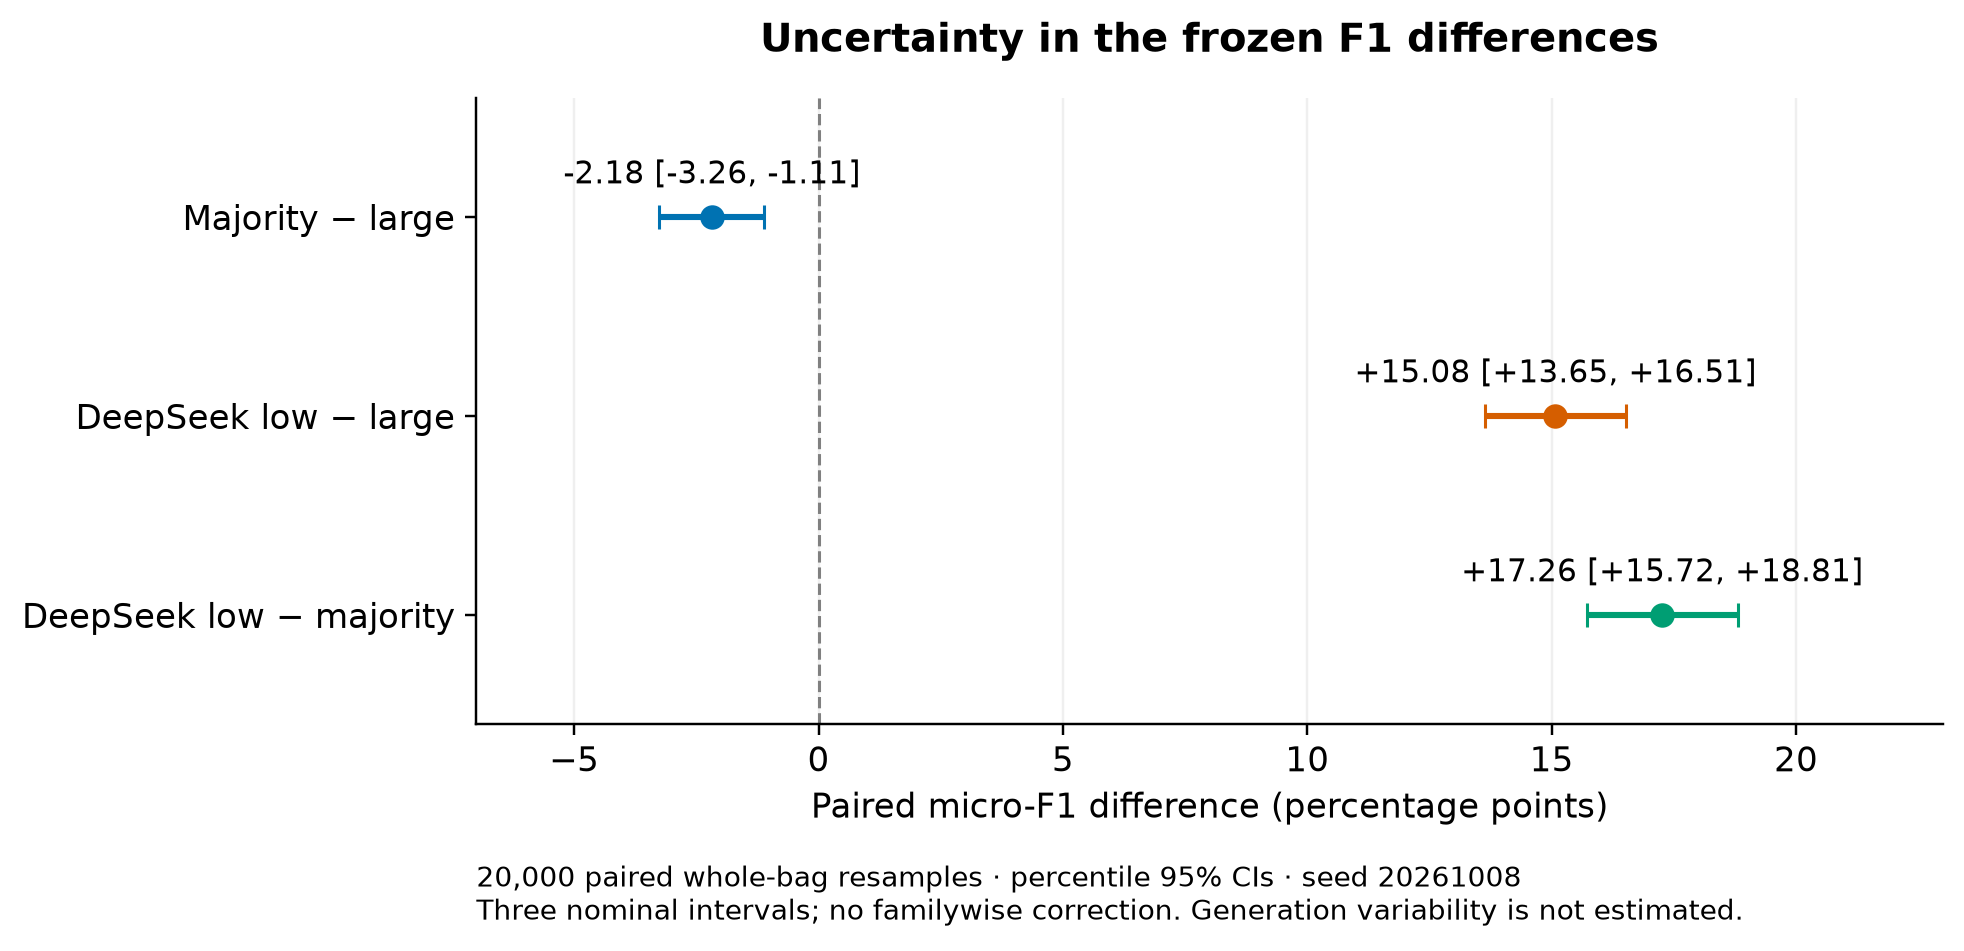

In [3]:
# Display paired F1 differences; uncertainty is computed on the differences directly.
name_by_system = dict(zip(SYSTEMS, NAMES, strict=True))
ci_rows = []
for row in report['uncertainty']['paired_f1_differences']:
    lo, hi = row['ci95_percentage_points']
    ci_rows.append({'Comparison': name_by_system[row['system_a']] + ' − ' + name_by_system[row['system_b']],
                    'F1 difference (pp)': row['f1_difference_percentage_points'],
                    '95% CI lower (pp)': lo, '95% CI upper (pp)': hi,
                    'Excludes zero': row['ci_excludes_zero']})
display(pd.DataFrame(ci_rows).round(2))
display(Image(filename=str(ROOT / 'results/figures/test_paired_f1_differences_20261008.png')))

## 3. Quality and recorded latency

Vertical error bars show bag-bootstrap uncertainty in F1. The horizontal axis uses mean **recorded seconds per bag**, on a logarithmic scale. Local CPU inference sums and remote request latency measure different execution scopes: the latter includes network and service time. Loading, preflight, idle gaps and backoff are excluded as specified in the frozen reports; the two interrupted API attempts are included in request time.

The majority requires all three local member inferences even when analysis reuses their caches. A point being slower here does not establish a hardware-normalised compute ratio. No confidence interval for timing is claimed.

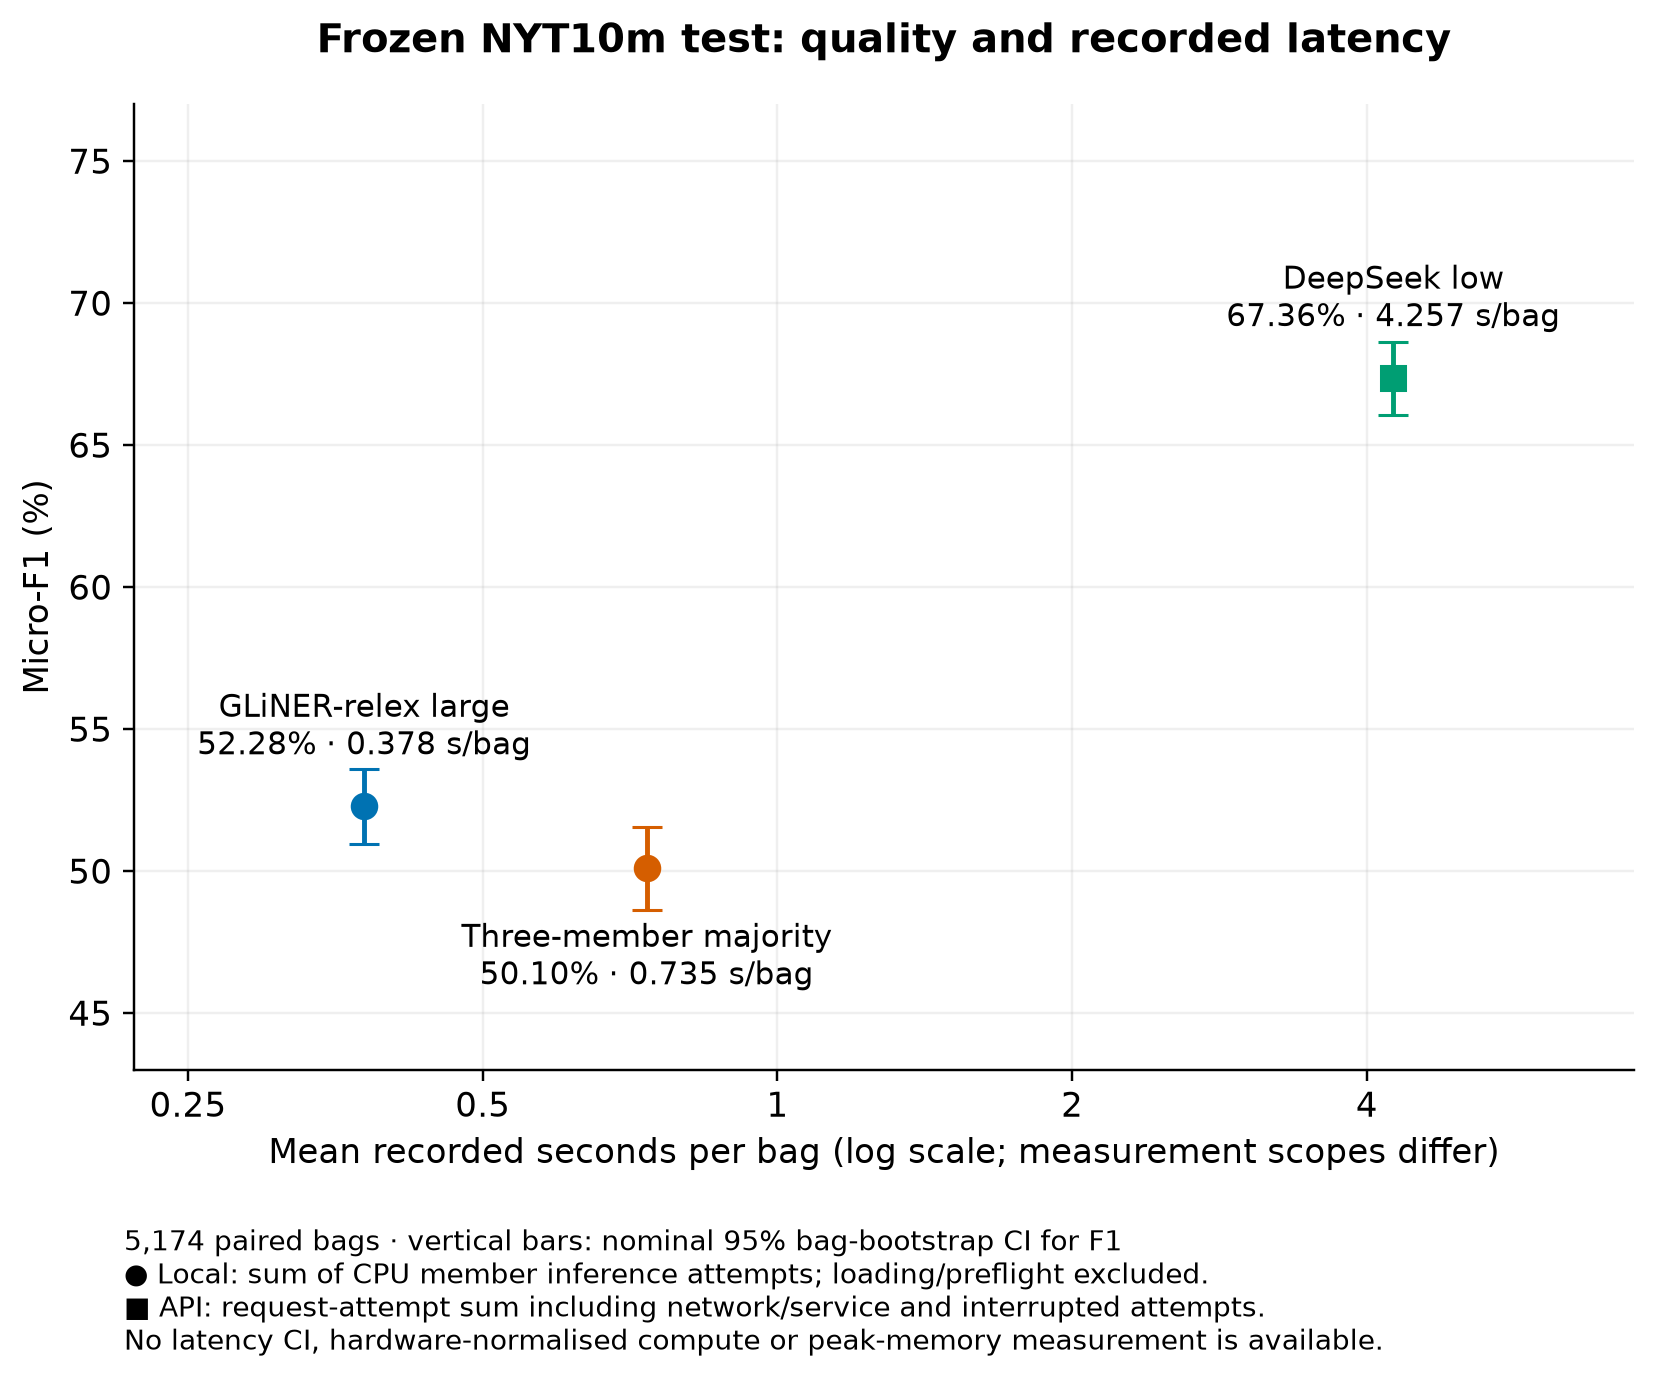

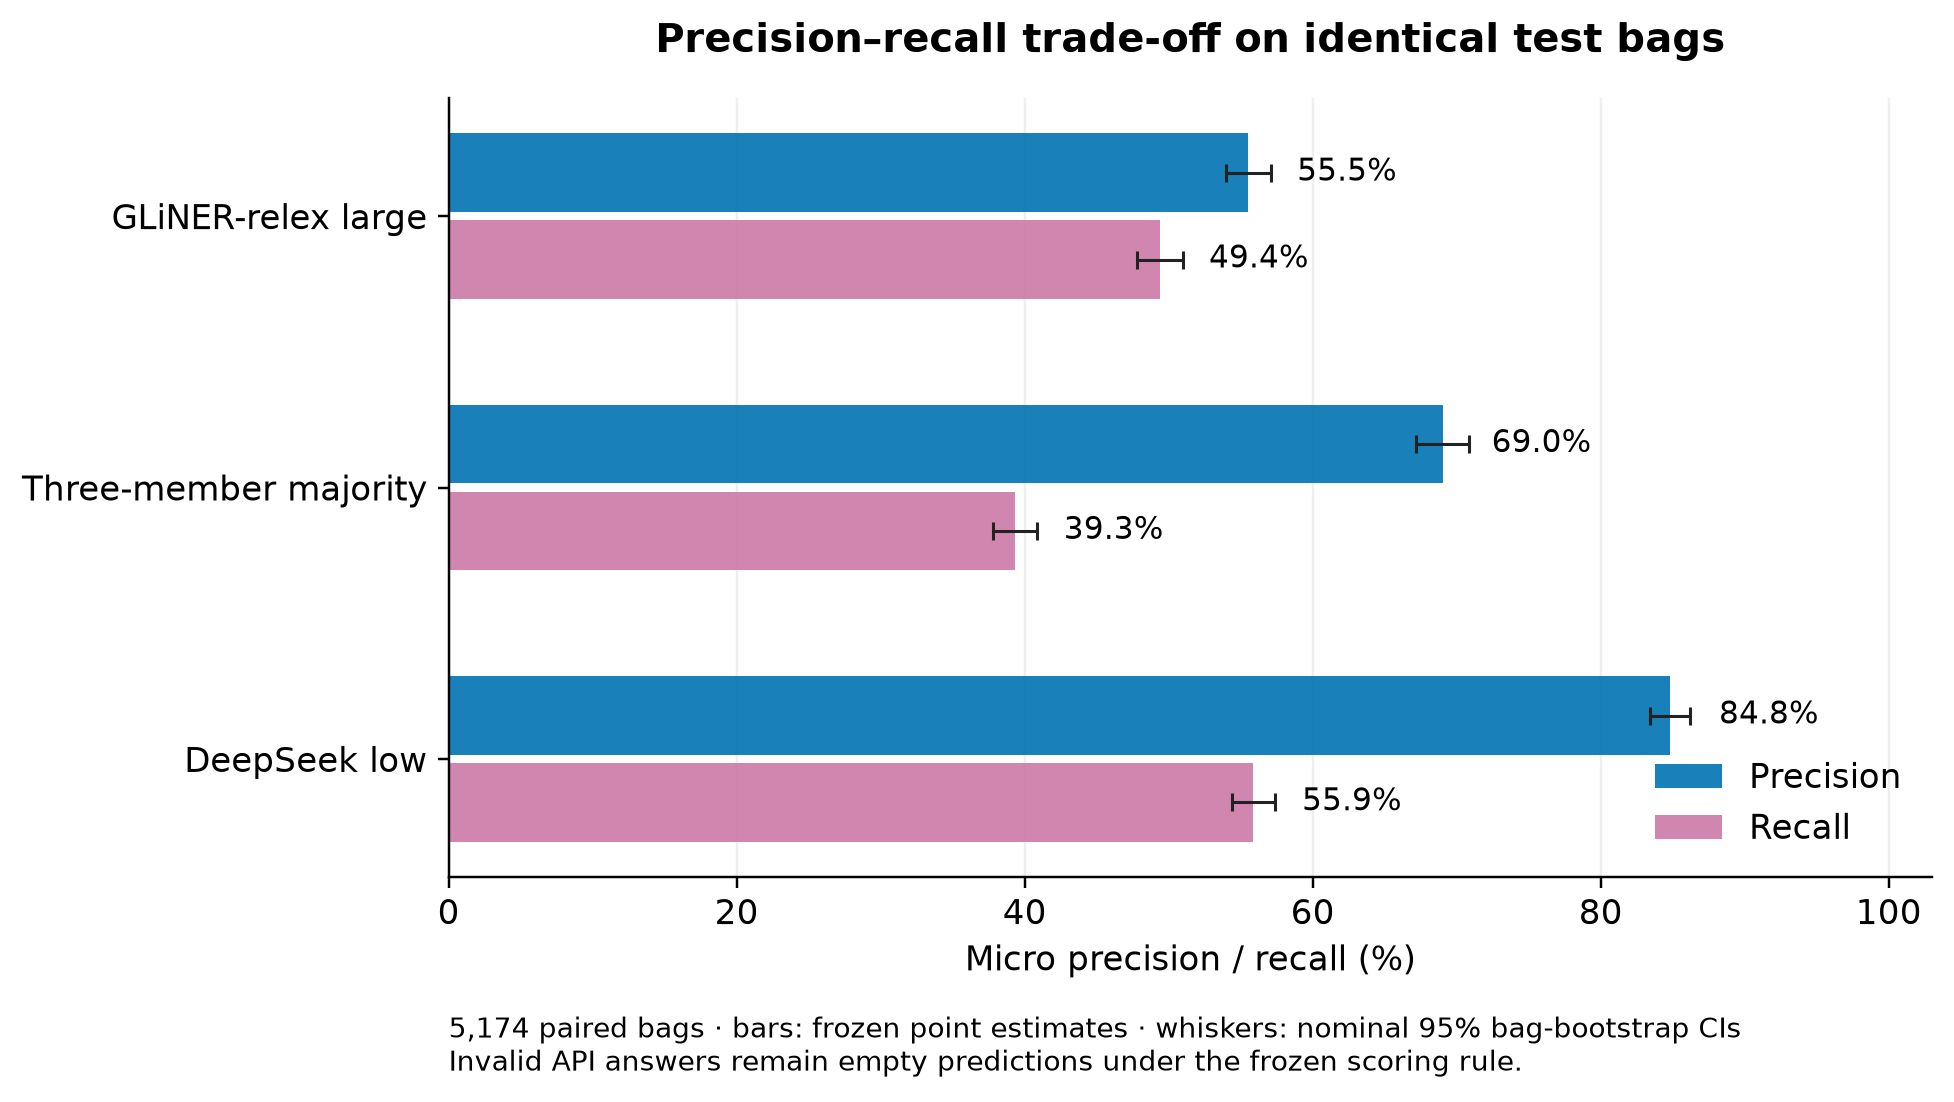

In [4]:
# Display the saved scientific figures; Matplotlib is not required for viewing.
display(Image(filename=str(ROOT / 'results/figures/test_quality_latency_20261008.png')))
display(Image(filename=str(ROOT / 'results/figures/test_precision_recall_20261008.png')))

## 4. Relations lost and recovered by majority voting

The following transitions compare the majority with **large alone** against the unchanged official reference. A *lost true positive* is a correct label predicted by large but rejected by the vote; a *recovered true positive* is a correct label absent from large but accepted by the vote. They are fact counts, not counts of bags.

Every rejected large label lacks support from **both** other members. Every newly accepted label has agreement from **base and GLiDRE** while large abstains. This is a diagnostic explanation of the frozen voting mechanism, not a test-guided proposal for new fusion rules.

In [5]:
# Summarise how voting changes correct and incorrect positive predictions.
d = report['ensemble_diagnostics']
display(pd.DataFrame([{'Transition': key.replace('_', ' '), 'Facts': d[key]} for key in
    ('removed_true_positives', 'added_true_positives', 'removed_false_positives', 'added_false_positives')]))
relation_rows = pd.DataFrame(d['per_relation'])
relation_rows['net_true_positives'] = relation_rows['added_true_positives'] - relation_rows['removed_true_positives']
relation_rows['net_false_positives'] = relation_rows['added_false_positives'] - relation_rows['removed_false_positives']
relation_rows['changed_facts'] = relation_rows[['removed_true_positives', 'added_true_positives',
                                             'removed_false_positives', 'added_false_positives']].sum(axis=1)
# The table orders descriptive errors by volume; it does not select settings.
display(relation_rows.sort_values(['changed_facts', 'relation'], ascending=[False, True])
        .drop(columns='changed_facts').reset_index(drop=True))

,Transition,Facts
0,removed true positives,468
1,added true positives,75
2,removed false positives,897
3,added false positives,42


,relation,manual_support,removed_true_positives,added_true_positives,removed_false_positives,added_false_positives,net_true_positives,net_false_positives
0,/location/location/contains,1153,276,2,145,0,-274,-145
1,/location/country/administrative_divisions,174,89,0,181,0,-89,-181
2,/location/country/capital,18,1,0,160,0,-1,-160
3,/location/region/capital,9,1,0,139,3,-1,-136
4,/people/person/ethnicity,13,4,0,61,8,-4,-53
5,/people/person/nationality,303,17,2,26,13,-15,-13
6,/time/event/locations,2,0,0,45,0,0,-45
7,/people/person/place_lived,1162,12,16,14,2,4,-12
8,/business/person/company,467,3,30,5,1,27,-4
9,/location/administrative_division/country,102,19,0,20,0,-19,-20


Voting removes **897 false positives** but also **468 true positives**, and adds **75 true positives** and **42 false positives**. The net effect is **393 fewer correct facts** and **855 fewer false positives**, across 1,200 changed bags.

The main recall loss concerns `contains` (**276 lost, 2 recovered; net −274**) and country administrative divisions (**89 lost, none recovered**). Together these account for 365/468 rejected correct facts (78.0%). Recoveries include person/company (**30 recovered, 3 lost; net +27**), place of death (**17 recovered, 2 lost; net +15**) and place lived (**16 recovered, 12 lost; net +4**).

The gains are therefore real but smaller than the losses. Precision rises from **55.52% to 69.02%**, while recall falls from **49.40% to 39.32%**. At the frozen primary micro-F1/time objective, large dominates this majority; an application assigning a different penalty to false positives could prefer a different trade-off, which was not the primary objective here.

In [6]:
# Show two deterministic, single-sentence examples from the saved diagnostic.
# Official annotations are retained; no additional manual adjudication is applied.
for category, example in report['ensemble_diagnostics']['examples'].items():
    title = 'Lost correct relation' if category == 'removed_true_positives' else 'Recovered correct relation'
    display(Markdown(f'**{title}: {example["head"]} → {example["tail"]}**'))
    display(Markdown('> ' + example['selected_sentences'][0]))
    display(Markdown('Official relation: `' + example['relation'] + '`'))
    display(pd.DataFrame([{'Member': member, 'Accepted labels': ', '.join(labels) or '[]'}
                          for member, labels in example['member_predictions'].items()]))

**Lost correct relation: Atlanta → Sweet Auburn**

> J. W. ROBINSON , 80 , remembers when the Sweet Auburn neighborhood in Atlanta was a mecca for aspiring African-American professionals like himself .

Official relation: `/location/location/contains`

,Member,Accepted labels
0,base,[]
1,large,/location/location/contains
2,glidre,[]


**Recovered correct relation: David Brooks → The New York Times**

> Rush Limbaugh suggested a theme song of Sir Mix-A-Lot 's '' Baby Got Back '' ; on '' The Chris Matthews Show '' on NBC , David Brooks , a columnist for The New York Times , suggested Hall and Oates 's '' Maneater '' ; on the Web site Townhall.com , Jon Sanders suggested R.E.M. 's '' It 's the End of the World as We Know It '' and Barry McGuire 's '' Eve of Destruction . ''

Official relation: `/business/person/company`

,Member,Accepted labels
0,base,/business/person/company
1,large,[]
2,glidre,/business/person/company


## 5. Separate cost dimensions

API expenditure, local CPU inference time, remote request latency and memory remain separate measurements. No zero-cost assumption is made for local compute. Peak memory was not logged and cannot be recovered from checkpoint sizes or prediction files. API provider memory is unavailable.

In [7]:
# Keep monetary expenditure and computational measurements in separate columns.
cost = report['cost_dimensions']
api_cost = cost['api_expenditure_USD']
cost_rows = []
for i, (name, row) in enumerate(zip(NAMES, report['primary_rows'], strict=True)):
    cost_rows.append({'System': name,
                     'Local CPU inference s': round(row['total_wall_s'], 2) if i < 2 else 'N/A',
                     'API request-attempt s': round(row['total_wall_s'], 2) if i == 2 else 'N/A',
                     'Mean recorded s/bag': round(row['mean_wall_s'], 3),
                     'API charge estimate USD': round(api_cost['completed_response_charge_estimate'], 6) if i == 2 else 'N/A',
                     'Unknown-charge reserve USD': round(api_cost['unknown_attempt_reserve'], 6) if i == 2 else 'N/A',
                     'Peak memory': 'Provider unavailable' if i == 2 else 'Not measured'})
display(pd.DataFrame(cost_rows))
print('Local monetary/energy cost: not measured.')
print('API usage plus reserve: USD', round(api_cost['usage_plus_reserve'], 6))
print('The reserve is not a known charge; reconstructed expenditure is not an invoice.')

,System,Local CPU inference s,API request-attempt s,Mean recorded s/bag,API charge estimate USD,Unknown-charge reserve USD,Peak memory
0,GLiNER-relex large,1957.52,N/A,0.378,N/A,N/A,Not measured
1,Three-member majority,3803.89,N/A,0.735,N/A,N/A,Not measured
2,DeepSeek low,N/A,22023.95,4.257,2.409668,0.012103,Provider unavailable


Local monetary/energy cost: not measured.
API usage plus reserve: USD 2.421771
The reserve is not a known charge; reconstructed expenditure is not an invoice.


## 6. Interpretation and reproducibility

The ensemble's **−2.18 F1-point difference** has a paired 95% interval **[−3.26, −1.11]**: within the bag-bootstrap assumptions, sampling uncertainty does not reverse its observed F1 deficit. It also requires **1.94×** large's local inference time. This supports a negative conclusion for the **tested members, thresholds and static majority**, not for ensembling in general.

DeepSeek low exceeds large by **15.08 F1 points [13.65, 16.51]** and majority by **17.26 points [15.72, 18.81]**. It has the strongest measured quality, at higher recorded request latency. Its 78 invalid outputs remain included. Recorded API expenditure is approximately **USD 2.41**, with **USD 0.0121** held separately for two unknown-charge attempts. Memory comparisons remain unavailable.

The report records the original fingerprint and input/reference hashes plus a saved-file inventory hash. The count archive and JSON are checked before display. The optional cells below recompute statistics or figures from public artifacts only; neither can generate model predictions. Exported PNG, SVG and PDF figures are stored in `results/figures/`.

In [8]:
# Optional numerical reproduction from the small public count archive only.
if RECOMPUTE_BOOTSTRAP:
    recomputed = paired_intervals(counts, replicates=20_000, seed=20261008)
    for saved, actual in zip(report['uncertainty']['paired_f1_differences'],
                              recomputed['paired_f1_differences'], strict=True):
        np.testing.assert_allclose(saved['ci95_percentage_points'], actual['ci95_percentage_points'], atol=1e-12)
    display(pd.DataFrame(recomputed['paired_f1_differences']))
else:
    print('Bootstrap recomputation disabled; the verified saved report is displayed above.')

# Optional figure regeneration requires the isolated plotting dependencies.
if REGENERATE_FIGURES:
    from plot_test_results import plot_results
    display(plot_results(ROOT))
else:
    print('Figure regeneration disabled; the exported figures are displayed above.')

Bootstrap recomputation disabled; the verified saved report is displayed above.
Figure regeneration disabled; the exported figures are displayed above.
